In [ ]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.1 MB/s eta 0:00:00


In [ ]:
import boto3
import pandas as pd
import joblib
import urllib.request


AWS_ACCESS_KEY_ID = ''
AWS_SECRET_ACCESS_KEY = ''
REGION_NAME = 'eu-north-1'
BUCKET_NAME = 'project-mds-innovations'
S3_FILE = 'titanic_clean.csv'
LOCAL_FILE = 'downloaded_titanic_clean.csv'


# Initialize the Boto3 S3 Client
s3_client = boto3.client(
    's3',
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=REGION_NAME
)

In [ ]:
# Download from S3 to Colab
print("Downloading dataset from S3...")
s3_client.download_file(
    BUCKET_NAME,
    S3_FILE,
    LOCAL_FILE
)

print("✅ Download complete!")

# Load into pandas dataframe
df = pd.read_csv(LOCAL_FILE)


✅ Download complete!


In [ ]:
# Preview data
print(df.head())
print(df.shape)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500      True       False        True  
1          PC 17599  71.2833     False       False       False  
2  STON/O2. 3101282   7.9250     False       False        True  
3            113803  53.1000     False       False        True  
4

In [ ]:
# View structure
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Sex_male     891 non-null    bool   
 10  Embarked_Q   891 non-null    bool   
 11  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(5), object(2)
memory usage: 65.4+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Check missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
dtype: int64


In [ ]:
# dummy variables
df_clean = df.copy()

# Drop text columns not useful for modeling
df_clean.drop(columns=['Name','Ticket'], inplace=True)

print(df_clean.head())

   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  \
0            1         0       3  22.0      1      0   7.2500      True   
1            2         1       1  38.0      1      0  71.2833     False   
2            3         1       3  26.0      0      0   7.9250     False   
3            4         1       1  35.0      1      0  53.1000     False   
4            5         0       3  35.0      0      0   8.0500      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


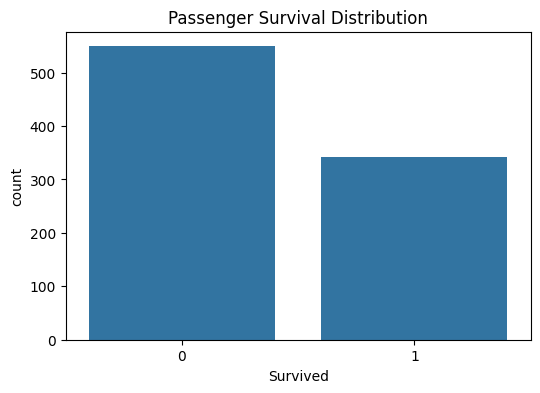

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title('Passenger Survival Distribution')
plt.show()

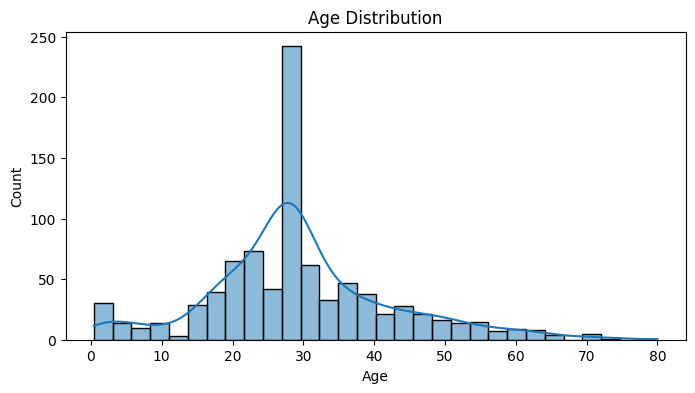

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.show()

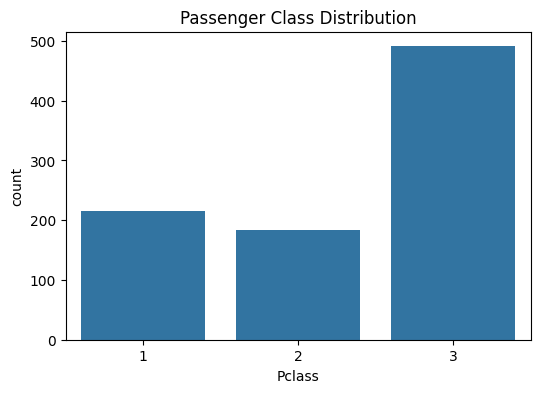

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df)

plt.title('Passenger Class Distribution')
plt.show()

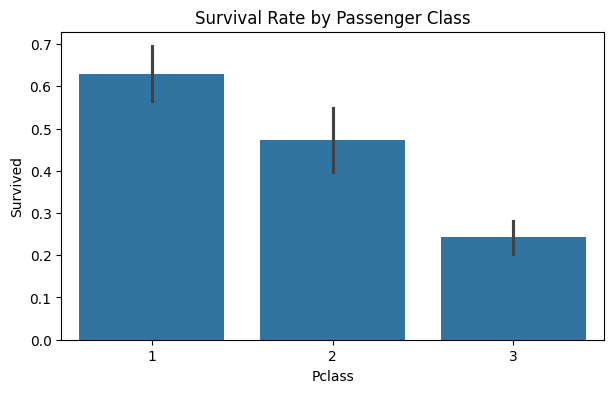

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='Pclass', y='Survived', data=df)

plt.title('Survival Rate by Passenger Class')
plt.show()

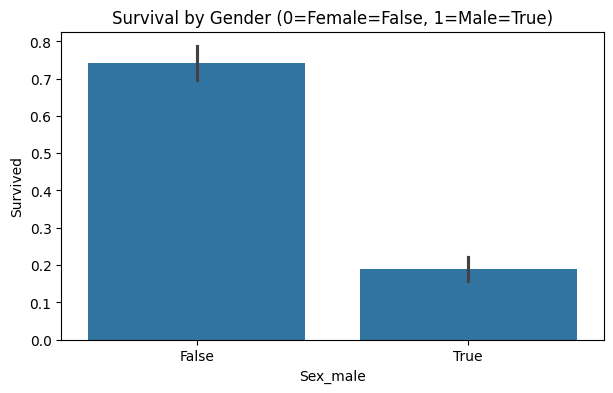

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='Sex_male', y='Survived', data=df)

plt.title('Survival by Gender (0=Female=False, 1=Male=True)')
plt.show()

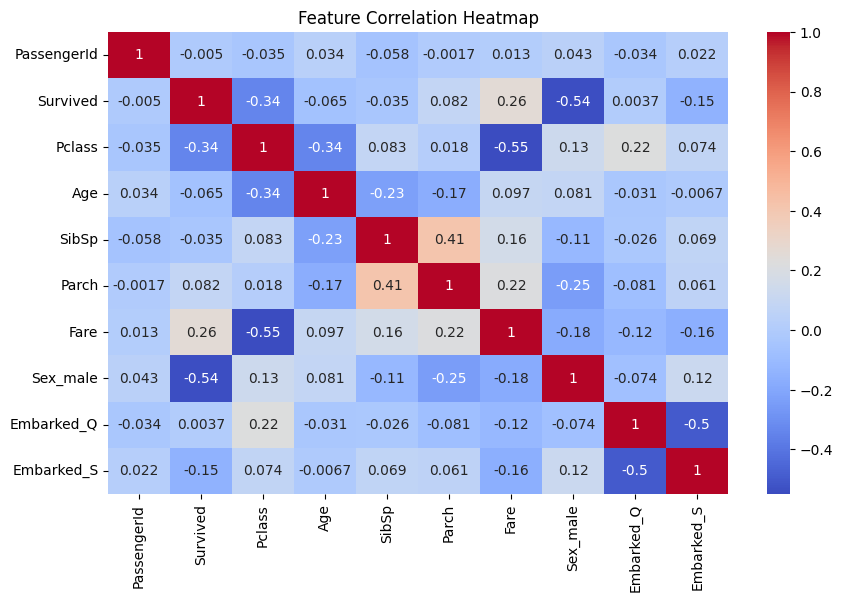

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
top5 = df.corr(numeric_only=True)['Survived'] \
          .drop('Survived') \
          .abs() \
          .sort_values(ascending=False) \
          .head(5)

print(top5)

Sex_male      0.543351
Pclass        0.338481
Fare          0.257307
Embarked_S    0.149683
Parch         0.081629
Name: Survived, dtype: float64


In [ ]:
# Feature Selection
X = df[['Sex_male','Pclass','Fare','Embarked_S','Parch']]
y = df['Survived']

from sklearn.model_selection import train_test_split

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (712, 5)
Test data shape: (179, 5)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Train model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predictions
log_preds = log_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from xgboost import XGBClassifier

# Train model
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_preds = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression Metrics")
print("Accuracy :", accuracy_score(y_test, log_preds))
print("Precision:", precision_score(y_test, log_preds))
print("Recall   :", recall_score(y_test, log_preds))
print("F1 Score :", f1_score(y_test, log_preds))

Logistic Regression Metrics
Accuracy : 0.7821229050279329
Precision: 0.7536231884057971
Recall   : 0.7027027027027027
F1 Score : 0.7272727272727273


In [ ]:
print("XGBoost Metrics")
print("Accuracy :", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds))
print("Recall   :", recall_score(y_test, xgb_preds))
print("F1 Score :", f1_score(y_test, xgb_preds))

XGBoost Metrics
Accuracy : 0.8044692737430168
Precision: 0.7746478873239436
Recall   : 0.7432432432432432
F1 Score : 0.7586206896551724


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, log_preds))

print("XGBoost")
print(classification_report(y_test, xgb_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

XGBoost
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



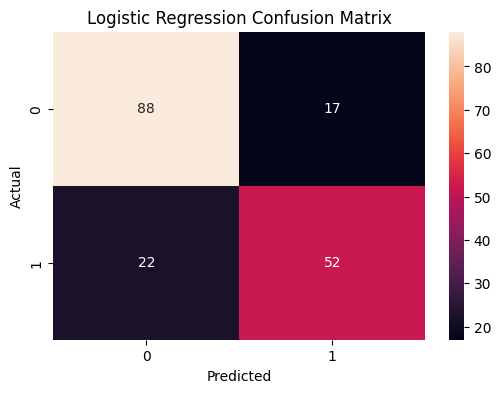

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, log_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

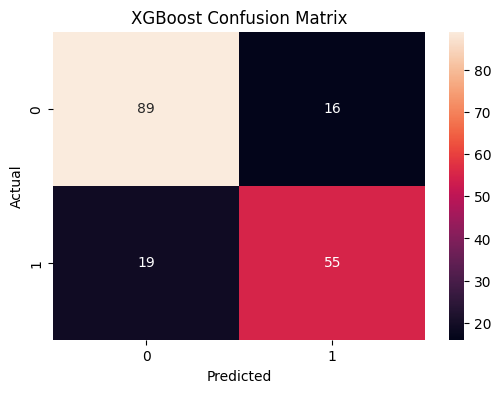

In [ ]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression AUC: 0.8624839124839123
XGBoost AUC: 0.8682110682110682


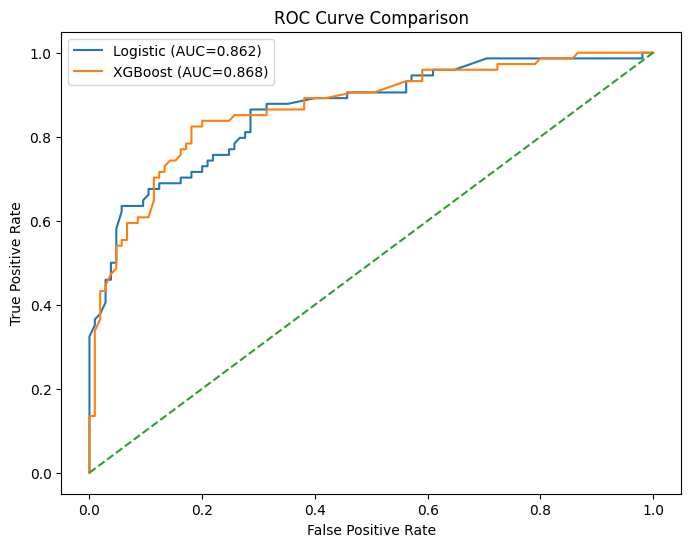

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities
log_probs = log_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

# ROC-AUC scores
log_auc = roc_auc_score(y_test, log_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("Logistic Regression AUC:", log_auc)
print("XGBoost AUC:", xgb_auc)

# ROC Curves
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# Plot both together
plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr,
         label=f'Logistic (AUC={log_auc:.3f})')

plt.plot(xgb_fpr, xgb_tpr,
         label=f'XGBoost (AUC={xgb_auc:.3f})')

# Random baseline
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import f1_score

# Calculate F1 scores
log_f1 = f1_score(y_test, log_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print("Logistic Regression F1 Score:", log_f1)
print("XGBoost F1 Score:", xgb_f1)

# Select best model
if xgb_f1 > log_f1:
    best_model = xgb_model
    print("✅ Best Model based on F1 Score: XGBoost")
else:
    best_model = log_model
    print("✅ Best Model based on F1 Score: Logistic Regression")

Logistic Regression F1 Score: 0.7272727272727273
XGBoost F1 Score: 0.7586206896551724
✅ Best Model based on F1 Score: XGBoost


In [ ]:
import pickle

# Save best model chosen from F1 comparison
with open("best_titanic_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("✅ Best model saved as best_titanic_model.pkl")

✅ Best model saved as best_titanic_model.pkl


In [ ]:
# Upload best model to S3
s3_client.upload_file(
    "best_titanic_model.pkl",
    "project-mds-innovations",
    "best_titanic_model.pkl"
)

print("✅ Model uploaded to AWS S3")

✅ Model uploaded to AWS S3


In [ ]:
!pip install PyGithub -q
from github import Github, GithubException, Auth
from datetime import datetime

# GitHub Credentials and Targeting
# ⚠️ SECURITY WARNING: Rotate these keys after your lecture!
STUDENT_TOKEN = ""
REPO_NAME = "samyupolice/XU-Projects.MDS-Innovations"
TARGET_FOLDER = "week-03-04-powerbi/machine_learning"
clean_filename = "best_titanic_model.pkl"

In [ ]:
# Authenticate with GitHub
# ----------------------------
auth = Auth.Token(STUDENT_TOKEN)
g = Github(auth=auth)

repo = g.get_repo(REPO_NAME)

print(f"Authenticated to repository: {repo.full_name}")

Authenticated to repository: samyupolice/XU-Projects.MDS-Innovations


In [ ]:
MODEL_FILE = "best_titanic_model.pkl"

In [ ]:
# Read model file
# Must be binary for .pkl

with open(MODEL_FILE, 'rb') as file:
    file_content = file.read()

github_path = f"{TARGET_FOLDER}/{MODEL_FILE}"

# Push model to GitHub
# Create if new, update if exists

try:
    repo.create_file(
        path=github_path,
        message=f"Upload ML model {MODEL_FILE}",
        content=file_content,
        branch="main"
    )
    print(f"✅ Successfully uploaded: {MODEL_FILE} to {TARGET_FOLDER}")

except GithubException as e:

    if e.status == 422: # File already exists, trigger update
        existing_file = repo.get_contents(github_path, ref="main")

        repo.update_file(
            path=github_path,
            message=f"Update ML model {MODEL_FILE}",
            content=file_content,
            sha=existing_file.sha,
            branch="main"
        )
        print(f"✅ Successfully updated: {MODEL_FILE} on GitHub")
    else:
        print(f"❌ Error uploading file: {e.data}")


✅ Successfully updated: best_titanic_model.pkl on GitHub


In [ ]:
# Save a local copy of current notebook into Colab runtime
from google.colab import _message

NOTEBOOK_FILE = "Titanic_ML_Task.ipynb"

# Download notebook JSON from current session
nb = _message.blocking_request('get_ipynb')['ipynb']

import json
with open(NOTEBOOK_FILE,"w") as f:
    json.dump(nb, f)

print("Notebook saved locally.")

Notebook saved locally.


In [ ]:
import os
print(os.listdir())

['.config', 'best_titanic_model.pkl', 'titanic_clean.csv', 'Titanic_ML_Task.ipynb', 'downloaded_titanic_clean.csv', 'sample_data']


In [86]:
NOTEBOOK_FILE = "Titanic_ML_Task.ipynb"   # replace with your actual notebook filename

from github import GithubException

# Read notebook in binary mode
with open(NOTEBOOK_FILE,"rb") as file:
    notebook_content = file.read()

github_path = f"{TARGET_FOLDER}/machine_learning/{NOTEBOOK_FILE}"

try:
    repo.create_file(
        path=github_path,
        message=f"Upload notebook {NOTEBOOK_FILE}",
        content=notebook_content,
        branch="main"
    )

    print(f"Notebook uploaded: {NOTEBOOK_FILE}")

except GithubException as e:

    if e.status == 422:
        existing_file = repo.get_contents(github_path, ref="main")

        repo.update_file(
            path=github_path,
            message=f"Update notebook {NOTEBOOK_FILE}",
            content=notebook_content,
            sha=existing_file.sha,
            branch="main"
        )

        print(f"Notebook updated: {NOTEBOOK_FILE}")

    else:
        print(e.data)

{'message': 'Repository rule violations found\n\nSecret detected in content\n\n', 'metadata': {'secret_scanning': {'bypass_placeholders': [{'placeholder_id': '3D1pHlRlPOVhBfskOnG3N29ZBx0', 'token_type': 'AWS_KEYID'}, {'placeholder_id': '3D1pHpRmMsgKy9qzSbBAofIubQ4', 'token_type': 'AWS_SECRET'}, {'placeholder_id': '3D2EuXseziZ5oALCbxxGsSs0C4M', 'token_type': 'GITHUB_PERSONAL_ACCESS_TOKEN'}]}}, 'documentation_url': 'https://docs.github.com/rest/repos/contents#create-or-update-file-contents', 'status': '409'}
